In [ ]:
# --- import Libreries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# Set plotting style
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# --- import dataset ---
df = pd.read_csv('mcdonalds_menu.csv')
print('\n')
print(df.info())
print('\n')
display(df.head(5))





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   item_id             80 non-null     object 
 1   item_name           80 non-null     object 
 2   category            80 non-null     object 
 3   description         80 non-null     object 
 4   price_usd           80 non-null     float64
 5   calories            80 non-null     int64  
 6   calories_from_fat   80 non-null     int64  
 7   total_fat_g         80 non-null     int64  
 8   saturated_fat_g     80 non-null     float64
 9   trans_fat_g         80 non-null     float64
 10  cholesterol_mg      80 non-null     int64  
 11  sodium_mg           80 non-null     int64  
 12  total_carbs_g       80 non-null     int64  
 13  dietary_fiber_g     80 non-null     float64
 14  sugars_g            80 non-null     float64
 15  protein_g           80 non-null     int64  
 16  calcium_

,item_id,item_name,category,description,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_gluten_free,is_dairy_free,is_low_calorie,is_high_protein,is_high_fiber,has_sizes,is_popular,is_limited_time,is_nationwide,serving_size,prep_time_minutes,price_per_calorie,protein_per_dollar,calorie_density,price_history
0,MCD_BURG_Big_Mac_325,Big Mac,Burgers,Signature big mac served hot and fresh,6.55,530,177,27,8.9,1.6,69,924,45,2.6,10.2,26,15,0.3,29,16,False,False,False,False,True,False,False,False,False,True,1 sandwich,2,12.36,3.97,0,"[{""year"": 2023, ""price_usd"": 7.12, ""price_chan..."
1,MCD_BURG_Quarter_Pounder_with_Cheese_180,Quarter Pounder with Cheese,Burgers,Signature quarter pounder with cheese served h...,7.03,515,188,26,8.6,3.8,43,1077,41,2.5,8.8,31,183,2.5,77,8,False,False,False,False,True,False,False,False,False,True,1 sandwich,5,13.65,4.41,0,"[{""year"": 2023, ""price_usd"": 7.42, ""price_chan..."
2,MCD_BURG_Cheeseburger_723,Cheeseburger,Burgers,Delicious cheeseburger from McDonald's,6.81,291,113,13,6.1,1.8,48,695,31,2.4,9.0,16,186,0.5,45,6,False,False,False,False,False,False,False,False,False,True,1 serving,4,23.40,2.35,0,"[{""year"": 2023, ""price_usd"": 7.34, ""price_chan..."
3,MCD_BURG_Double_Cheeseburger_771,Double Cheeseburger,Burgers,Freshly made double cheeseburger,5.84,448,156,23,8.4,2.9,7,1133,36,2.6,3.9,26,161,1.2,8,6,False,False,False,False,True,False,False,False,False,True,1 drink,4,13.04,4.45,0,"[{""year"": 2023, ""price_usd"": 6.34, ""price_chan..."
4,MCD_BURG_McDouble_710,McDouble,Burgers,Signature mcdouble served hot and fresh,5.05,397,86,21,9.4,1.9,74,906,35,3.1,5.8,23,70,1.5,11,24,False,False,False,False,True,False,False,True,False,True,1 drink,9,12.72,4.55,0,"[{""year"": 2023, ""price_usd"": 5.43, ""price_chan..."


In [ ]:
df.columns

Index(['item_id', 'item_name', 'category', 'description', 'price_usd',
       'calories', 'calories_from_fat', 'total_fat_g', 'saturated_fat_g',
       'trans_fat_g', 'cholesterol_mg', 'sodium_mg', 'total_carbs_g',
       'dietary_fiber_g', 'sugars_g', 'protein_g', 'calcium_mg', 'iron_mg',
       'vitamin_a_iu', 'vitamin_c_mg', 'is_vegetarian', 'is_gluten_free',
       'is_dairy_free', 'is_low_calorie', 'is_high_protein', 'is_high_fiber',
       'has_sizes', 'is_popular', 'is_limited_time', 'is_nationwide',
       'serving_size', 'prep_time_minutes', 'price_per_calorie',
       'protein_per_dollar', 'calorie_density', 'price_history'],
      dtype='object')

In [ ]:
# --- Null and Duplicates
print(df.isnull().sum())
print(df.duplicated().sum())

item_id               0
item_name             0
category              0
description           0
price_usd             0
calories              0
calories_from_fat     0
total_fat_g           0
saturated_fat_g       0
trans_fat_g           0
cholesterol_mg        0
sodium_mg             0
total_carbs_g         0
dietary_fiber_g       0
sugars_g              0
protein_g             0
calcium_mg            0
iron_mg               0
vitamin_a_iu          0
vitamin_c_mg          0
is_vegetarian         0
is_gluten_free        0
is_dairy_free         0
is_low_calorie        0
is_high_protein       0
is_high_fiber         0
has_sizes             0
is_popular            0
is_limited_time       0
is_nationwide         0
serving_size          0
prep_time_minutes     0
price_per_calorie     0
protein_per_dollar    0
calorie_density       0
price_history         0
dtype: int64
0


Ok let's Analyse each columns, it seems like there is no duplicated or null value insted there is some invalid values.

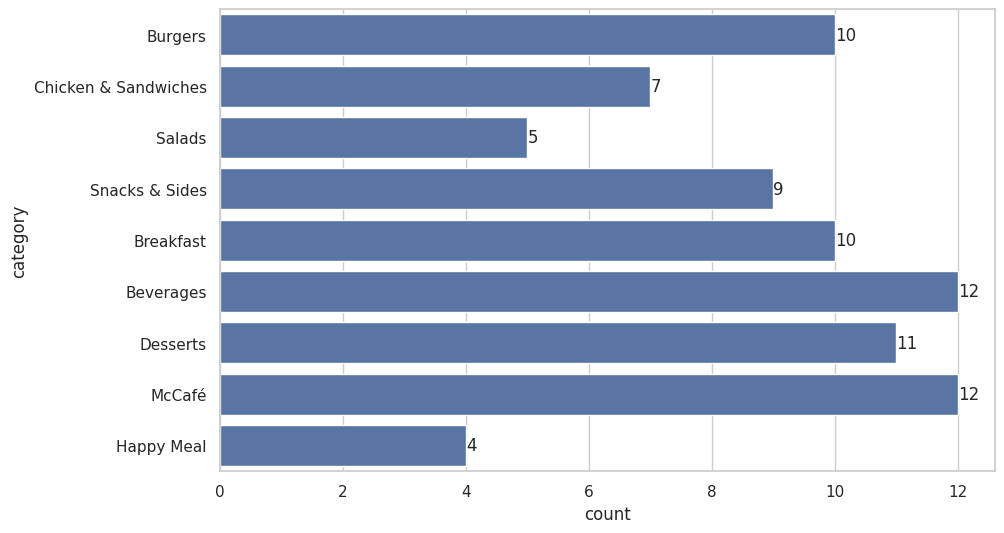

In [ ]:
x = sns.countplot(df['category'])
for i in x.containers:
    x.bar_label(i)

In [ ]:
df['calorie_density'].value_counts()

,count
calorie_density,
0,80


In [ ]:
# --- wheather negetive or zero number present ---
result = (df.select_dtypes(include=['number']) < 0).any()
display(result[result == True])
result2 = (df.select_dtypes(include=['number']) == 0).any()
display(result2[result2 == True])

,0
saturated_fat_g,True
trans_fat_g,True
dietary_fiber_g,True
sugars_g,True


,0
calories_from_fat,True
total_fat_g,True
saturated_fat_g,True
trans_fat_g,True
sodium_mg,True
total_carbs_g,True
protein_g,True
iron_mg,True
protein_per_dollar,True
calorie_density,True


<Axes: xlabel='trans_fat_g', ylabel='Count'>

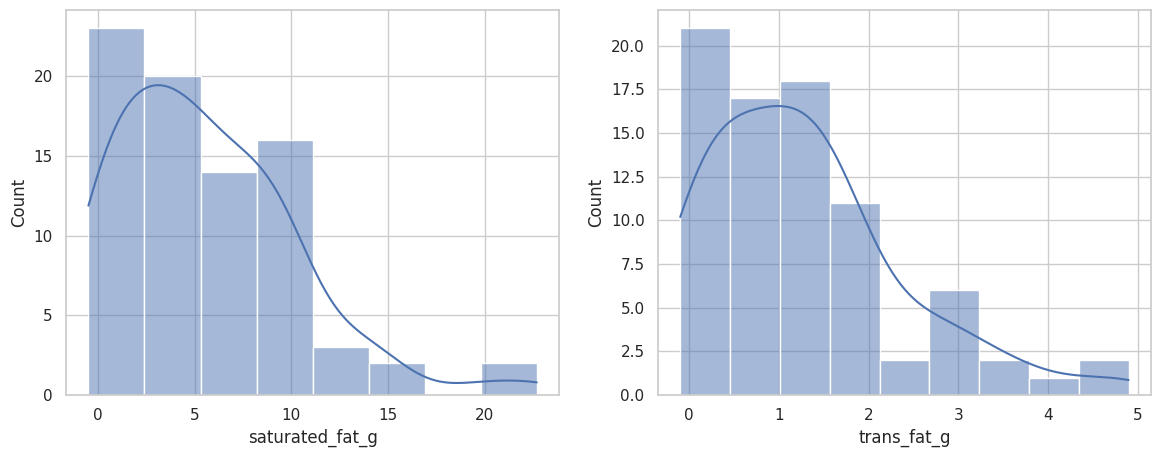

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['saturated_fat_g'], kde = True)
plt.subplot(1, 2, 2)
sns.histplot(df['trans_fat_g'], kde = True)


In [ ]:
df[df['trans_fat_g'] <= 0]

,item_id,item_name,category,description,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_gluten_free,is_dairy_free,is_low_calorie,is_high_protein,is_high_fiber,has_sizes,is_popular,is_limited_time,is_nationwide,serving_size,prep_time_minutes,price_per_calorie,protein_per_dollar,calorie_density,price_history
41,MCD_BEVE_Coca-Cola_(Small)_607,Coca-Cola (Small),Beverages,Freshly made coca-cola (small),1.63,157,76,0,0.0,0.0,73,40,40,3.5,14.3,0,210,0.1,95,15,False,False,False,False,False,False,True,False,False,True,1 serving,10,10.38,0.00,0,"[{""year"": 2023, ""price_usd"": 1.72, ""price_chan..."
42,MCD_BEVE_Coca-Cola_(Medium)_972,Coca-Cola (Medium),Beverages,Classic McDonald's coca-cola (medium),3.22,220,88,0,-0.5,-0.1,18,23,60,5.5,17.8,0,79,0.2,100,8,False,False,False,False,False,True,True,False,False,True,1 drink,7,14.64,0.00,0,"[{""year"": 2023, ""price_usd"": 3.42, ""price_chan..."
45,MCD_BEVE_Sprite_(Small)_816,Sprite (Small),Beverages,Classic McDonald's sprite (small),2.41,147,42,0,0.0,0.0,54,50,36,4.3,8.5,0,154,0.6,49,27,False,False,False,True,False,False,True,False,False,True,1 drink,6,16.39,0.00,0,"[{""year"": 2023, ""price_usd"": 2.62, ""price_chan..."
46,MCD_BEVE_Fanta_Orange_(Small)_416,Fanta Orange (Small),Beverages,Delicious fanta orange (small) from McDonald's,1.19,151,65,0,0.0,0.0,45,29,44,3.2,6.9,1,128,2.0,92,24,False,False,False,False,False,False,True,False,False,True,1 item,7,7.88,0.84,0,"[{""year"": 2023, ""price_usd"": 1.28, ""price_chan..."
49,MCD_BEVE_Iced_Tea_701,Iced Tea,Beverages,Signature iced tea served hot and fresh,2.85,4,1,0,-0.3,-0.1,63,0,2,0.1,0.3,1,275,0.4,58,11,False,False,False,True,False,False,False,False,False,False,1 serving,8,712.50,0.35,0,"[{""year"": 2023, ""price_usd"": 3.06, ""price_chan..."
50,MCD_BEVE_Sweet_Tea_294,Sweet Tea,Beverages,Classic McDonald's sweet tea,2.44,125,61,0,0.0,0.0,56,0,31,4.5,11.1,1,50,2.9,47,17,False,False,False,True,False,False,False,False,False,True,1 drink,3,19.52,0.41,0,"[{""year"": 2023, ""price_usd"": 2.62, ""price_chan..."
70,MCD_MCCA_Americano_(Small)_213,Americano (Small),McCafé,Delicious americano (small) from McDonald's,3.26,7,3,0,-0.3,-0.1,77,28,3,0.3,0.4,0,147,0.7,15,1,False,False,False,True,False,False,True,True,False,True,1 drink,10,465.71,0.00,0,"[{""year"": 2023, ""price_usd"": 3.45, ""price_chan..."


In [ ]:
df['expected_calories_from_fat'] = df['total_fat_g'] * 9
df[['calories_from_fat', 'total_fat_g', 'expected_calories_from_fat']]

,calories_from_fat,total_fat_g,expected_calories_from_fat
0,177,27,243
1,188,26,234
2,113,13,117
3,156,23,207
4,86,21,189
...,...,...,...
75,135,9,81
76,223,20,180
77,170,22,198
78,183,16,144


In [ ]:
# --- if total fat == 0 then every fat is 0 ---
# Set saturated_fat_g and trans_fat_g to 0 where total_fat_g is 0
df.loc[df['total_fat_g'] == 0, ['saturated_fat_g', 'trans_fat_g']] = 0
df.loc[df['total_fat_g'] == 0, 'calories_from_fat']
df[df['trans_fat_g'] < 0]

,item_id,item_name,category,description,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_gluten_free,is_dairy_free,is_low_calorie,is_high_protein,is_high_fiber,has_sizes,is_popular,is_limited_time,is_nationwide,serving_size,prep_time_minutes,price_per_calorie,protein_per_dollar,calorie_density,price_history,expected_calories_from_fat


In [ ]:
display(df[(df['dietary_fiber_g'] <= 0) | (df['sugars_g'] <= 0)])
df.loc[
    (df['dietary_fiber_g'] < 0) & (df['sugars_g'] < 0),
    ['dietary_fiber_g', 'sugars_g']
] = 0

,item_id,item_name,category,description,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_gluten_free,is_dairy_free,is_low_calorie,is_high_protein,is_high_fiber,has_sizes,is_popular,is_limited_time,is_nationwide,serving_size,prep_time_minutes,price_per_calorie,protein_per_dollar,calorie_density,price_history,expected_calories_from_fat
44,MCD_BEVE_Diet_Coke_(Small)_570,Diet Coke (Small),Beverages,Classic McDonald's diet coke (small),1.67,3,0,1,0.4,0.1,21,16,0,-0.1,-0.3,0,195,1.9,30,15,False,False,True,True,False,False,True,False,False,True,1 item,9,556.67,0.0,0,"[{""year"": 2023, ""price_usd"": 1.81, ""price_chan...",9


In [ ]:
df['d_price_per_calorie'] = df['price_usd'] / df['calories']
df[['price_usd', 'price_per_calorie', 'd_price_per_calorie']]

,price_usd,price_per_calorie,d_price_per_calorie
0,6.55,12.36,0.012358
1,7.03,13.65,0.013650
2,6.81,23.40,0.023402
3,5.84,13.04,0.013036
4,5.05,12.72,0.012720
...,...,...,...
75,2.47,8.26,0.008261
76,5.24,11.47,0.011466
77,5.99,14.19,0.014194
78,6.41,15.37,0.015372


In [ ]:
df['d_protein_per_dollar'] = df['price_usd'] / df['protein_g']
df[['price_usd', 'protein_g', 'd_protein_per_dollar', 'protein_per_dollar']]

,price_usd,protein_g,d_protein_per_dollar,protein_per_dollar
0,6.55,26,0.251923,3.97
1,7.03,31,0.226774,4.41
2,6.81,16,0.425625,2.35
3,5.84,26,0.224615,4.45
4,5.05,23,0.219565,4.55
...,...,...,...,...
75,2.47,6,0.411667,2.43
76,5.24,21,0.249524,4.01
77,5.99,17,0.352353,2.84
78,6.41,18,0.356111,2.81


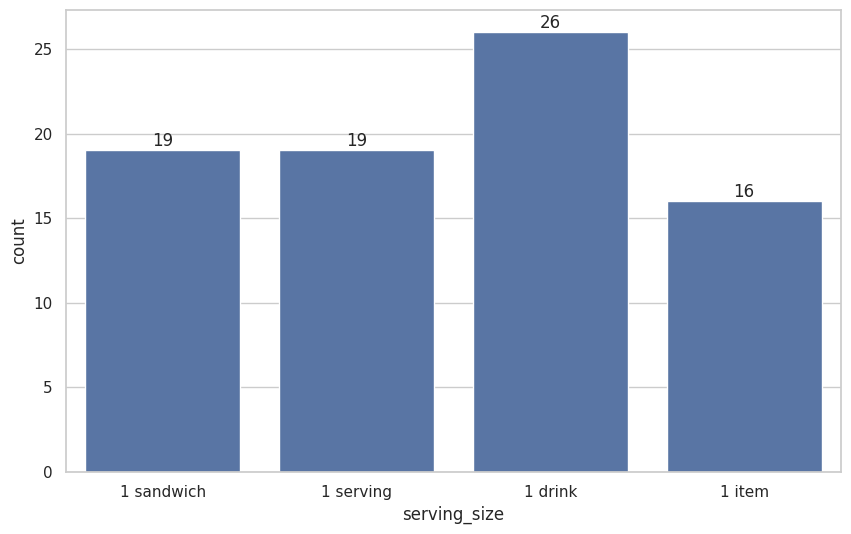

In [ ]:
x = sns.countplot(x=df['serving_size'])
for i in x.containers:
    x.bar_label(i)
plt.show()

In [ ]:
df['serving_size'].value_counts()

,count
serving_size,
1 drink,26
1 sandwich,19
1 serving,19
1 item,16


In [ ]:
df['price_history'][0]

'[{"year": 2023, "price_usd": 7.12, "price_change_percent": 8.7}, {"year": 2024, "price_usd": 6.76, "price_change_percent": 3.2}, {"year": 2025, "price_usd": 6.65, "price_change_percent": 1.5}, {"year": 2026, "price_usd": 6.55, "price_change_percent": 0}]'

In [ ]:
import json

def extract_yearly_prices(row):
    try:
        # Load the stringified JSON array
        history = json.loads(row)
        # Map year to its price
        return {f"{item['year']}_price_usd": item['price_usd'] for item in history}
    except (json.JSONDecodeError, TypeError, KeyError):
        return {}

# Apply the helper function and expand into new columns
prices_df = df['price_history'].apply(extract_yearly_prices).apply(pd.Series)

# Concatenate with original dataframe
df = pd.concat([df, prices_df], axis=1)

# Display the newly created columns
display(df[['item_name', '2023_price_usd', '2024_price_usd', '2025_price_usd', '2026_price_usd']].head())

,item_name,2023_price_usd,2024_price_usd,2025_price_usd,2026_price_usd
0,Big Mac,7.12,6.76,6.65,6.55
1,Quarter Pounder with Cheese,7.42,7.29,7.19,7.03
2,Cheeseburger,7.34,7.11,7.13,6.81
3,Double Cheeseburger,6.34,6.21,5.96,5.84
4,McDouble,5.43,5.31,5.13,5.05


In [ ]:
col_to_delete = ['item_id', 'description', 'price_per_calorie', 'calorie_density',
                 'd_price_per_calorie', 'd_protein_per_dollar', 'protein_per_dollar', 'is_gluten_free',
                 'is_dairy_free',	'is_low_calorie',	'is_high_protein',	'is_high_fiber',	'has_sizes',	'is_popular',
                 'serving_size', 'price_history', '2023_price_usd',	'2024_price_usd',	'2025_price_usd',	'2026_price_usd',
                 'expected_calories_from_fat']

df.drop(columns=col_to_delete, inplace=True)
df.head()

,item_name,category,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_limited_time,is_nationwide,prep_time_minutes
0,Big Mac,Burgers,6.55,530,177,27,8.9,1.6,69,924,45,2.6,10.2,26,15,0.3,29,16,False,False,True,2
1,Quarter Pounder with Cheese,Burgers,7.03,515,188,26,8.6,3.8,43,1077,41,2.5,8.8,31,183,2.5,77,8,False,False,True,5
2,Cheeseburger,Burgers,6.81,291,113,13,6.1,1.8,48,695,31,2.4,9.0,16,186,0.5,45,6,False,False,True,4
3,Double Cheeseburger,Burgers,5.84,448,156,23,8.4,2.9,7,1133,36,2.6,3.9,26,161,1.2,8,6,False,False,True,4
4,McDouble,Burgers,5.05,397,86,21,9.4,1.9,74,906,35,3.1,5.8,23,70,1.5,11,24,False,False,True,9


In [ ]:
df.to_csv('final_mcdonalds_menu.csv', index=False)
print("Saved current DataFrame to 'final_mcdonalds_menu.csv'")

Saved current DataFrame to 'final_mcdonalds_menu.csv'


## Note

- 80 rows, 36 columns.
- Item ID is useless; gotta remove that.
- description is unneeded for analysis.
- Is serving size an object? It is correct; I just checked.
- Category can be used for compare price or nutretional value across different categories. 9 categories in total.
- Calorei Dencity every value is 0 so it good to delete it.  
- Many nutretional value is flaged as negetive which is impossible but being zero can be possible.
- there is total fat, saturated and trans but the non saturated one is missing that is the reasion for the sum not adding up.
- converting all fat and cal from fat to 0 if the total fat is 0.
- checking the correctness of price_per_calorie feature. it doesn't make any sence, I can't figure out the units of measurement use in here so it is good to just delete the column same for protein_per_dollar.
- I don't think I needed these in the analysis:  is_gluten_free,	is_dairy_free,	is_low_calorie,	is_high_protein,	is_high_fiber,	has_sizes,	is_popular, serving_size.
- extract columns 2023_price_usd, 2024_price_usd, 2025_price_usd, and 2026_price_usd from price_history.
- I just noticed The dataset records a decrease in the Big Mac price from $7.12 in 2023 to $6.55 in 2026 (about 8%). External figures I found show an increase in the U.S. average price over a similar period.
- Finaly delete all the mess that I created along with incorrect or useless columns.